In [55]:
import os
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Get File path and load the csv data

In [ ]:
from util.data_path import corn_price_avg as data_file

In [57]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [58]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [59]:
y_train = train["price"].asfreq("MS")
y_test = future["price"].asfreq("MS")

SEQ_LEN = 12
PRED_LEN = 12

### Predict the data for the next year

In [60]:
sf_data = (
    y_train.rename("y")
    .to_frame()
    .assign(ds=lambda df: df.index, unique_id="cassava")
    .reset_index(drop=True)
)

# Modified StatsForecast setup with compatible parameters
sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=12,  # Monthly data
            start_p=1,
            start_q=1,
            max_p=3,
            max_q=3,
            d=1,
            seasonal=True,
            stepwise=True,
            trace=True,  # Show model selection process
            approximation=False,
        )
    ],
    freq="MS",  # Month start
)

### Compare The Error of a predicted data and the actual data in a table format

Model information not available in this version of statsforecast


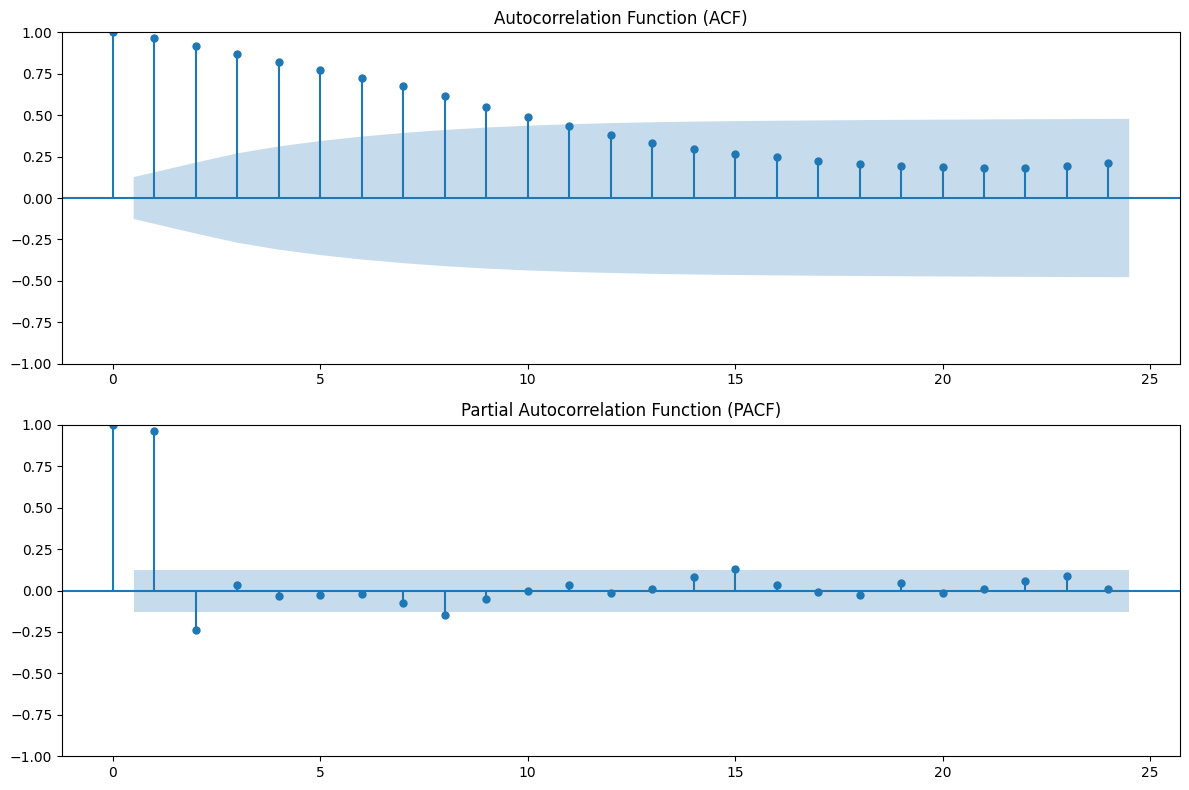

In [61]:
# Add diagnostics to check model parameters
try:
    model_info = sf.models[0].model_
    print("Selected ARIMA Model Information:")
    print(model_info)
except AttributeError:
    print("Model information not available in this version of statsforecast")

# Plot ACF and PACF to understand time series characteristics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_train, lags=24, ax=ax1)
ax1.set_title("Autocorrelation Function (ACF)")
plot_pacf(y_train, lags=24, ax=ax2)
ax2.set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

Time Series Analysis for Model Selection:
----------------------------------------
ADF Statistic: -0.9698
p-value: 0.7641
Critical Values:
	1%: -3.4598
	5%: -2.8745
	10%: -2.5737
Series is non-stationary according to ADF test


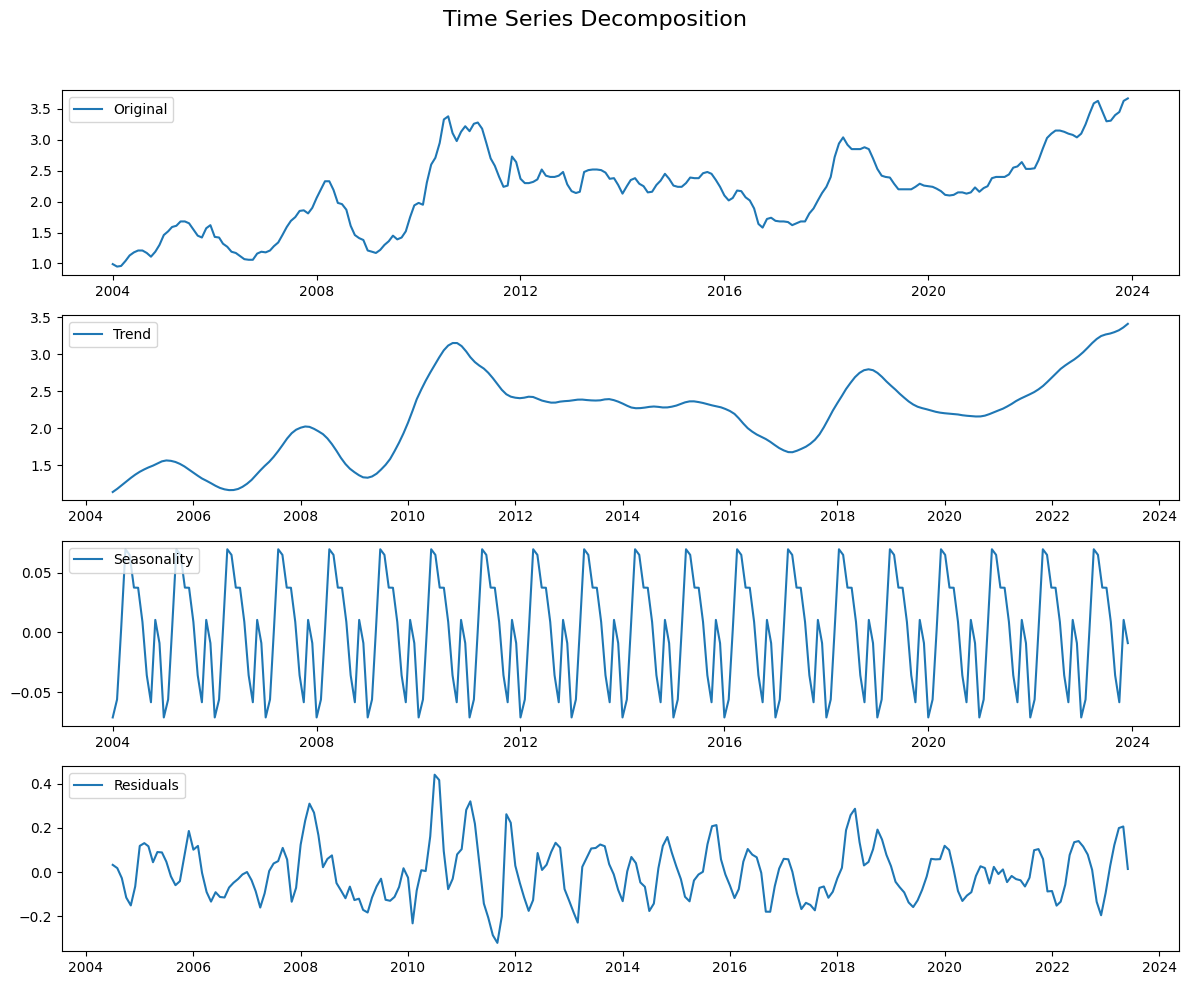


Seasonality Analysis:
Seasonal component range: -0.07 to 0.07
Seasonality strength (relative to residuals): 0.37


In [62]:
# Analyze the time series data for stationarity and seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("Time Series Analysis for Model Selection:")
print("-" * 40)

# 1. Check for stationarity using ADF Test
# Null hypothesis: time series is non-stationary
adf_result = adfuller(y_train.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value:.4f}")
print(
    f"Series is {'stationary' if adf_result[1] < 0.05 else 'non-stationary'} according to ADF test"
)

# 2. Decompose the time series to see trend and seasonality
try:
    decomposition = seasonal_decompose(y_train.dropna(), model="additive", period=12)

    fig = plt.figure(figsize=(12, 10))
    fig.suptitle("Time Series Decomposition", fontsize=16)

    # Original
    ax1 = plt.subplot(411)
    ax1.plot(y_train, label="Original")
    ax1.legend(loc="upper left")

    # Trend
    ax2 = plt.subplot(412)
    ax2.plot(decomposition.trend, label="Trend")
    ax2.legend(loc="upper left")

    # Seasonality
    ax3 = plt.subplot(413)
    ax3.plot(decomposition.seasonal, label="Seasonality")
    ax3.legend(loc="upper left")

    # Residuals
    ax4 = plt.subplot(414)
    ax4.plot(decomposition.resid, label="Residuals")
    ax4.legend(loc="upper left")

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    print("\nSeasonality Analysis:")
    print(
        f"Seasonal component range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}"
    )
    print(
        f"Seasonality strength (relative to residuals): {decomposition.seasonal.std() / decomposition.resid.std():.2f}"
    )

except Exception as e:
    print(f"Could not perform seasonal decomposition: {e}")

In [63]:
sf_forecasts = sf.fit_predict(df=sf_data, h=12)
arima_sf = sf_forecasts.set_index("ds")["AutoARIMA"]


error = y_test - arima_sf
abs_error = abs(error)

mae_arima = mean_absolute_error(y_test, arima_sf)
error = pd.DataFrame(
    {
        "actual": y_test,
        "arima_sf": arima_sf,
        "mae_arima": abs_error,
    }
)



ARIMA(1,1,1)(1,0,1)[12] with drift        :-443.394883274136

ARIMA(0,1,0) with drift        :-367.34450305924906

ARIMA(1,1,0)(1,0,0)[12] with drift        :-426.7909986268354

ARIMA(0,1,1)(0,0,1)[12] with drift        :-434.1760789821875

ARIMA(0,1,0)                   :-366.9628800211112

ARIMA(1,1,1)(0,0,1)[12] with drift        :-434.55191558623824

ARIMA(1,1,1)(1,0,0)[12] with drift        :-434.71030343091934

ARIMA(1,1,1)(2,0,1)[12] with drift        :inf

ARIMA(1,1,1)(2,0,1)[12] with drift        :inf

ARIMA(1,1,1)(1,0,2)[12] with drift        :-443.6789725614607

ARIMA(1,1,1)(1,0,2)[12] with drift        :-443.6789725614607

ARIMA(1,1,1)(0,0,2)[12] with drift        :-438.38612949928785

ARIMA(1,1,1)(0,0,2)[12] with drift        :-438.38612949928785

ARIMA(1,1,1)(2,0,2)[12] with drift        :-437.62534293966615

ARIMA(1,1,1)(2,0,2)[12] with drift        :-437.62534293966615

ARIMA(0,1,1)(1,0,2)[12] with drift        :-438.21313937690053

ARIMA(1,1,0)(1,0,2)[12] with drift  

In [64]:
# Inspect the model after fitting
try:
    # Try different attribute names that might contain model info
    if hasattr(sf.models[0], "model_"):
        print("ARIMA Model Information via model_ attribute:")
        print(sf.models[0].model_)
    elif hasattr(sf.models[0], "fitted_"):
        print("ARIMA Model Information via fitted_ attribute:")
        print(sf.models[0].fitted_)
    elif hasattr(sf.models[0], "params"):
        print("ARIMA Model Parameters:")
        print(sf.models[0].params)
    else:
        # Direct attribute access
        print("Model attributes available:")
        for attr in dir(sf.models[0]):
            if not attr.startswith("_"):
                print(f"- {attr}")
except Exception as e:
    print(f"Could not access model information: {e}")

# Print the forecast object information
print("\nForecast object structure:")
print(f"- sf_forecasts columns: {sf_forecasts.columns.tolist()}")
print(f"- sf_forecasts shape: {sf_forecasts.shape}")

Model attributes available:
- D
- alias
- allowdrift
- allowmean
- approximation
- biasadj
- blambda
- d
- fit
- forecast
- forward
- ic
- max_D
- max_P
- max_Q
- max_d
- max_order
- max_p
- max_q
- method
- new
- nmodels
- predict
- predict_in_sample
- prediction_intervals
- season_length
- seasonal
- seasonal_test
- seasonal_test_kwargs
- start_P
- start_Q
- start_p
- start_q
- stationary
- stepwise
- test
- test_kwargs
- trace
- truncate
- uses_exog

Forecast object structure:
- sf_forecasts columns: ['unique_id', 'ds', 'AutoARIMA']
- sf_forecasts shape: (12, 3)


In [65]:
forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "ARIMA"
forecast_dir.mkdir(exist_ok=True)


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(
        f"ARIMA Forecast Results for {data_file.parent.name.capitalize()} Prices (2024) {timestamp}\n"
    )
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in arima_sf.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Arima_sf Price: {arima_sf.mean():.2f}\n")
    f.write(f"Min Arima_sf Price: {arima_sf.min():.2f}\n")
    f.write(f"Max Arima_sf Price: {arima_sf.max():.2f}\n")
    f.write(f"Standard Deviation: {arima_sf.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\ARIMA\cassava_forecast.txt
File size: 524 bytes


### Plot The predicted data compare to an actual data

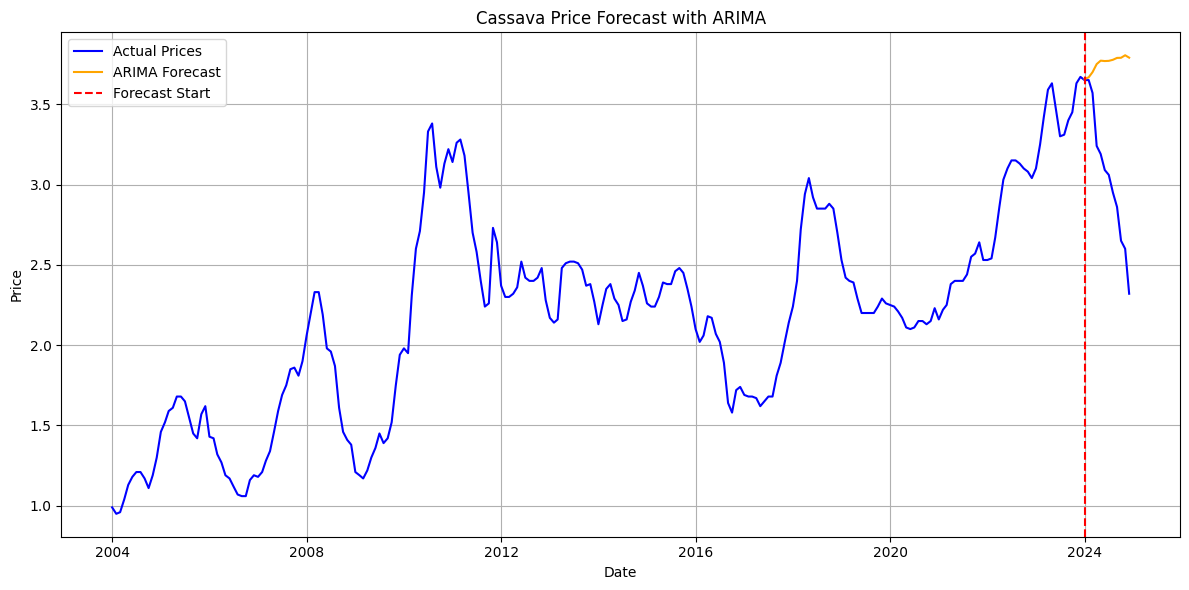

In [66]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(arima_sf.index, arima_sf, label="ARIMA Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_2567}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cassava Price Forecast with ARIMA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [67]:
# Try multiple ARIMA variants to compare performance
from statsforecast.models import ARIMA

# Define models with better error handling
try:
    sf_multi = StatsForecast(
        models=[
            AutoARIMA(season_length=12, approximation=False),
            # Try simpler manual ARIMA models
            ARIMA(p=1, d=1, q=0, season_length=12),  # Simple model
            ARIMA(p=1, d=1, q=1, season_length=12),  # Standard (p,d,q)=(1,1,1)
            ARIMA(p=2, d=1, q=2, season_length=12),  # More complex
        ],
        freq="MS",
    )

    # Create a new dataframe to avoid interference with existing model
    sf_data_multi = (
        y_train.rename("y")
        .to_frame()
        .assign(ds=lambda df: df.index, unique_id="cassava")
        .reset_index(drop=True)
    )

    print("Fitting multiple ARIMA models for comparison...")
    sf_multi_forecasts = sf_multi.fit_predict(df=sf_data_multi, h=12)

    # Compare results of different models
    results = {}
    plt.figure(figsize=(14, 7))
    plt.plot(long.index, long["price"], label="Actual Prices", color="blue", alpha=0.7)

    # Get all column names except 'ds' and 'unique_id'
    model_columns = [
        col for col in sf_multi_forecasts.columns if col not in ["ds", "unique_id"]
    ]

    for model_name in model_columns:
        model_forecast = sf_multi_forecasts.set_index("ds")[model_name]
        mae = mean_absolute_error(y_test, model_forecast)
        accuracy = 100 - (mae / y_test.mean() * 100)
        results[model_name] = {"MAE": mae, "Accuracy": accuracy}

        # Plot each model forecast
        plt.plot(
            model_forecast.index,
            model_forecast.values,
            label=f"{model_name} (MAE: {mae:.3f})",
            linestyle="--",
        )

    plt.axvline(
        x=pd.Timestamp(f"{gregorian_2567}-01-01"),
        color="red",
        linestyle="--",
        label="Forecast Start",
    )
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title("Cassava Price Forecast - Multiple ARIMA Models Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print comparison results
    print("\n--- Model Comparison Results ---")
    for model, metrics in results.items():
        print(f"{model}:")
        print(f"  MAE: {metrics['MAE']:.3f}")
        print(f"  Accuracy: {metrics['Accuracy']:.2f}%")
        print("-" * 30)

    # Identify the best model based on MAE
    best_model = min(results.items(), key=lambda x: x[1]["MAE"])
    print(
        f"\nBest model: {best_model[0]} with MAE: {best_model[1]['MAE']:.3f} and Accuracy: {best_model[1]['Accuracy']:.2f}%"
    )

except Exception as e:
    print(f"Error in multi-model comparison: {e}")
    print(
        "Try running the models individually to identify which one is causing the issue."
    )

Error in multi-model comparison: ARIMA.__init__() got an unexpected keyword argument 'p'
Try running the models individually to identify which one is causing the issue.
